In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [4]:
import io
df = pd.read_csv(io.BytesIO(uploaded['Iris.csv']))

In [5]:
df = pd.read_csv("Iris.csv")

In [6]:
X = df.iloc[:, 1:5].values
y = df.iloc[:, -1].values

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [9]:
k = 3
model = KNeighborsClassifier(n_neighbors=k)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [11]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

In [12]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

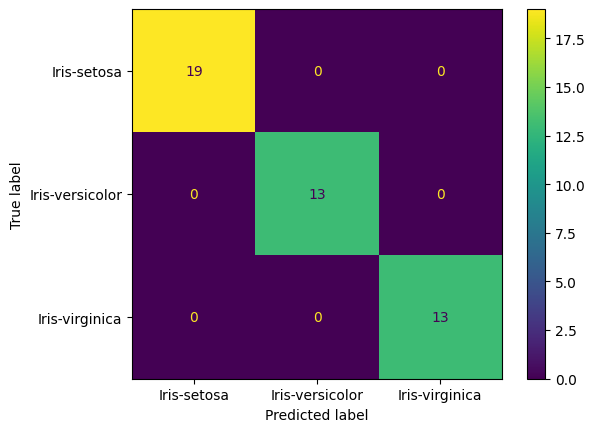

In [13]:
disp.plot()

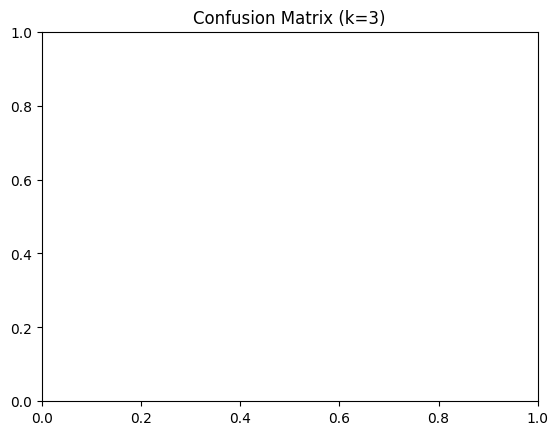

In [14]:
plt.title(f"Confusion Matrix (k={k})")
plt.show()

In [15]:
from matplotlib.colors import ListedColormap

In [16]:
X_2d = X_scaled[:, :2]

In [17]:
X_train_2d, X_test_2d = train_test_split(X_2d, test_size=0.3, random_state=42)

In [25]:
from sklearn.preprocessing import LabelEncoder

In [26]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [27]:
model_2d = KNeighborsClassifier(n_neighbors=k)
model_2d.fit(X_train_2d, y_encoded[:len(X_train_2d)])

KNeighborsClassifier(n_neighbors=3)

In [28]:
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

In [29]:
plt.figure(figsize=(8, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ['red', 'green', 'blue']

<Figure size 800x600 with 0 Axes>

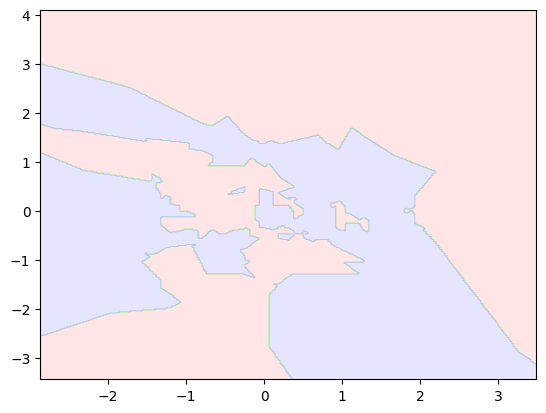

In [30]:
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

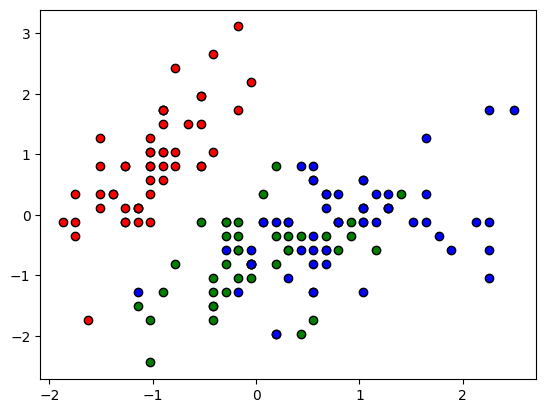

In [31]:
for idx, class_label in enumerate(le.classes_):
    plt.scatter(X_2d[y_encoded == idx, 0], X_2d[y_encoded == idx, 1],
                c=cmap_bold[idx], label=class_label, edgecolor='k')

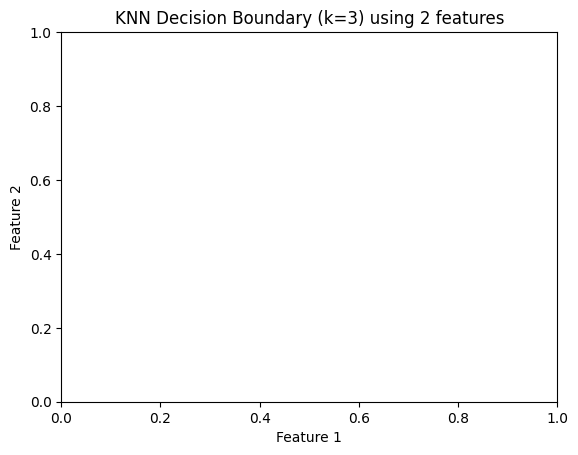

In [33]:
plt.title(f"KNN Decision Boundary (k={k}) using 2 features")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()